In [2]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Feature Importance
import matplotlib.pyplot as plt



In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Decision tree

In [5]:
baseline = DecisionTreeClassifier(random_state=42)

baseline.fit(X_train, y_train)

prediction = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, prediction)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.9473684210526315


Random forest

In [6]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9649122807017544


In [7]:
import sys
print(sys.executable)
print(sys.version)

/Users/krish/data-science/.venv/bin/python
3.13.14 (v3.13.14:fd17997c386, Jun 10 2026, 08:55:00) [Clang 21.0.0 (clang-2100.1.1.101)]


In [8]:

# XGBoost
from xgboost import XGBClassifier

# LightGBM
from lightgbm import LGBMClassifier

Gradient boosting 

In [9]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

gb_prediction = gb.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_prediction)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.956140350877193


In [10]:
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

prediction = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, prediction)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9649122807017544


LightGBM

In [11]:
lgbm = LGBMClassifier(
    random_state=42
)

lgbm.fit(X_train, y_train)

prediction = lgbm.predict(X_test)

lgbm_accuracy = accuracy_score(y_test, prediction)

print("LightGBM Accuracy:", lgbm_accuracy)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [12]:
param_grid = {
    "n_estimators": [50,100,200],
    "max_depth": [3,5,10,None],
    "min_samples_split": [2,5,10]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters")

print(grid.best_params_)

print("Best CV Score")

print(grid.best_score_)

Best Parameters
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score
0.9626373626373625


In [13]:
best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("Test Accuracy")

print(accuracy_score(y_test, prediction))

Test Accuracy
0.9649122807017544


In [14]:
param_dist = {
    "n_estimators":[50,100,200,300],
    "max_depth":[3,5,8,10,None],
    "min_samples_split":[2,4,6,8],
    "max_features":["sqrt","log2",None]
}

random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random.fit(X_train,y_train)

print(random.best_params_)
print(random.best_score_)

{'n_estimators': 100, 'min_samples_split': 8, 'max_features': 'sqrt', 'max_depth': 8}
0.9538461538461538


In [15]:
importance = best_model.feature_importances_

importance_df = pd.DataFrame({

    "Feature":X.columns,

    "Importance":importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                 Feature  Importance
23            worst area    0.128510
27  worst concave points    0.128365
22       worst perimeter    0.127080
7    mean concave points    0.119750
20          worst radius    0.069274
6         mean concavity    0.055773
0            mean radius    0.050440
3              mean area    0.042591
26       worst concavity    0.040713
2         mean perimeter    0.038352


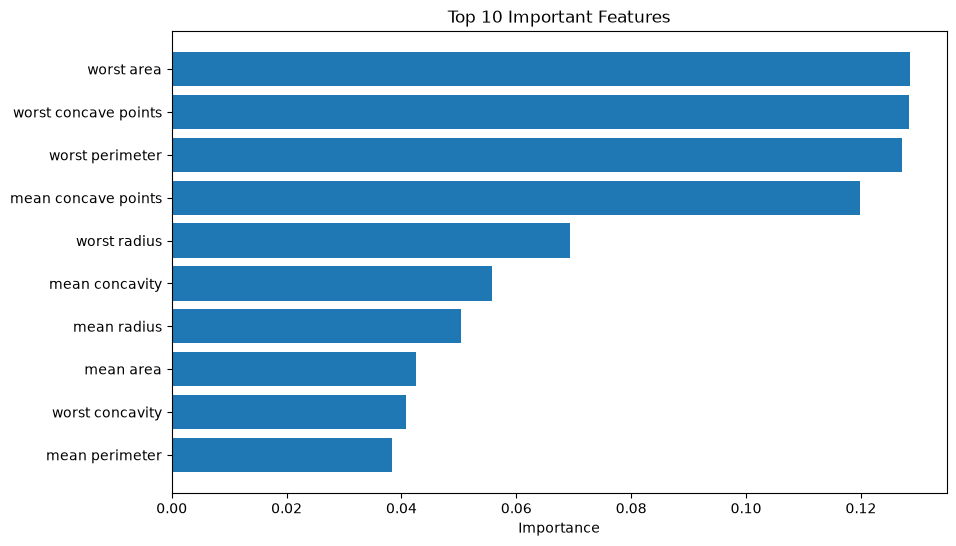

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [17]:
comparison = pd.DataFrame({

"Model":[
"Decision Tree",
"Random Forest",
"Gradient Boosting",
"XGBoost",
"LightGBM"
],

"Accuracy":[
baseline_accuracy,
rf_accuracy,
gb_accuracy,
xgb_accuracy,
lgbm_accuracy
]

})

comparison

,Model,Accuracy
0,Decision Tree,0.947368
1,Random Forest,0.964912
2,Gradient Boosting,0.956140
3,XGBoost,0.964912
4,LightGBM,0.964912


## Task 


In [18]:
print(baseline_accuracy)

0.9473684210526315


In [19]:
grid.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

In [21]:
prediction = best_model.predict(X_test)

tuned_accuracy = accuracy_score(
    y_test,
    prediction
)

print(tuned_accuracy)

0.9649122807017544


tuned_accuracy > baseline_accuracy
the task is successful.


In [22]:
experiment_log = pd.DataFrame({

"Experiment":[
"Baseline Decision Tree",
"Random Forest",
"Gradient Boosting",
"XGBoost",
"LightGBM",
"Tuned Random Forest"
],

"Parameters":[
"Default",
"Default",
"Default",
"Default",
"Default",
str(grid.best_params_)
],

"Accuracy":[
baseline_accuracy,
rf_accuracy,
gb_accuracy,
xgb_accuracy,
lgbm_accuracy,
tuned_accuracy
]

})

experiment_log

,Experiment,Parameters,Accuracy
0,Baseline Decision Tree,Default,0.947368
1,Random Forest,Default,0.964912
2,Gradient Boosting,Default,0.956140
3,XGBoost,Default,0.964912
4,LightGBM,Default,0.964912
5,Tuned Random Forest,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.964912


In [23]:
experiment_log.to_csv(
    "experiment_log.csv",
    index=False
)

print("Experiment log saved successfully!")

Experiment log saved successfully!


In [24]:
print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [25]:
X.fillna(X.mean(), inplace=True)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


## Reflection

### Challenges
- Selecting appropriate hyperparameters.
- Comparing multiple ensemble algorithms fairly.

### Improvements
- Achieved higher accuracy than the baseline using GridSearchCV.
- Learned how ensemble methods reduce overfitting.

### Remaining Work
- Try Bayesian Optimization or Optuna for faster tuning.
- Experiment with feature engineering before tuning.